<div align="center" >
    <br /><br />
    <h1>Universidad de Sevilla</h1>
    <h2>Escuela Técnica Superior de Ingeniería Informática</h2>
    <h3>Grado en Ingeniería del Software</h3>
    <img src="images/logo_us.png" alt="Logo Universidad de Sevilla" width="250" />
    <br />
    <hr />
    <br />
    <h1>Modelado con Node2Vec sobre Cora</h1>
    <h2>Embeddings de grafos y clasificación supervisada</h2>
    <br />
    <hr />
    <br />
    <p><strong>Asignatura:</strong> Inteligencia Artificial</p>
    <p><strong>Grupo:</strong> Aprendizaje Automático Relacional - G5</p>
    <p><strong>Curso Académico:</strong> 2025/2026</p>
</div>

<br /><br /><br /><br />

<div align="right" >
    <p><strong>Autores:</strong><br />
    Juan Antonio Fernández Ruiz<br />
    Eulogio Reyes Díaz<br />
</div>

<div align="right" >
    <p><strong>Fecha:</strong> 7 de Junio de 2026</p>
</div>

<br /><br />

# Modelado con Node2Vec


## Indice de contenidos

- [0. Introduccion y objetivo](#0-introducción-y-objetivo)
- [1. Enfoque metodologico](#1-enfoque-metodológico)
- [2. Configuracion y carga de datos](#2-configuracion-y-carga-de-datos)
- [3. Generacion de embeddings con Node2Vec](#3-generación-de-embeddings-con-node2vec)
- [4. Preparacion para clasificacion](#4-preparación-para-clasificación)
- [5. Modelos y validacion cruzada](#5-modelos-y-validacion-cruzada)
- [6. Evaluacion final en test](#6-evaluacion-final-en-test)
- [7. Comparativa con baseline de caracteristicas manuales](#7-comparativa-con-baseline-de-caracteristicas-manuales)
- [8. Persistencia de artefactos](#8-persistencia-de-artefactos)
- [9. Conclusiones y siguientes pasos](#9-conclusiones-y-siguientes-pasos)

## 0. Introducción y objetivo

En esta tarea implementamos Node2Vec para aprender representaciones vectoriales de nodos del grafo Cora y reutilizarlas en clasificación supervisada multiclase.

**Objetivo:** comparar el rendimiento de modelos clásicos entrenados con embeddings Node2Vec frente al baseline de características manuales de la Tarea 2.1.

**Salida esperada:** tablas de validación cruzada y test, modelo final persistido y evidencia comparativa para la selección global.

## 1. Enfoque metodológico

El flujo de trabajo sigue tres fases:

1. **Aprendizaje de embeddings con Node2Vec** mediante caminatas aleatorias sobre el grafo.
2. **Entrenamiento de modelos de clasificación** con búsqueda de hiperparámetros usando validación cruzada estratificada.
3. **Evaluación y comparativa final** contra el baseline manual para analizar la contribución de la representación relacional.

## 2. Configuracion y carga de datos

Importamos dependencias, reconstruimos el grafo de Cora y alineamos los identificadores de nodos con sus etiquetas de clase.

In [19]:

import pandas as pd
import networkx as nx
from node2vec import Node2Vec

from pathlib import Path

# Directorio base del proyecto
BASE_DIR = Path.cwd().parent


# Rutas al dataset
data_path = BASE_DIR / "data" / "cora"
path_cora_content = data_path / "cora.content"
path_cora_cites = data_path / "cora.cites"

# 1. Reconstruir el grafo G y recuperar los ID's de los nodos.
cora_cites = pd.read_csv(path_cora_cites, sep='\t', header=None, names=['cited_paper_id', 'citing_paper_id'])
cora_cites = cora_cites.astype(str)
G = nx.from_pandas_edgelist(cora_cites, source='cited_paper_id', target='citing_paper_id')

# carga también las etiquetas (labels) y los paper_ids
cora_content = pd.read_csv(path_cora_content, sep='\t', header=None)
paper_ids = cora_content[0].astype(str).tolist()
labels = cora_content[1434].tolist()  # La última columna contiene las etiquetas




## 3. Generación de embeddings con Node2Vec

Node2Vec simula caminatas aleatorias para capturar estructura local y global del grafo. Luego, un modelo tipo Word2Vec aprende vectores densos para cada nodo.

Con estos embeddings construimos una matriz de entrada compacta para clasificación.

In [20]:
# 2. Inicializar Node2Vec
# parameters:
# dimensions: El tamaño del vector latente resultante (ej. 64 variables en lugar de 1433)
# walk_length: Cuántos saltos da el caminante en cada ruta
# num_walks: Cuántas rutas distintas inicia desde cada nodo
node2vec = Node2Vec(G, dimensions=64, walk_length=30, num_walks=200, workers=4, seed=42)

# 3. Entrenar el modelo (Aprender las representaciones latentes)
print("Entrenando el modelo Node2Vec (esto puede tardar unos minutos)...")
modelo_n2v = node2vec.fit(window=10, min_count=1, batch_words=4)

# 4. Extraer los embeddings (vectores) en el mismo orden que nuestros paper_ids
embeddings = [modelo_n2v.wv[nodo] for nodo in paper_ids]

# 5. Crear nuestro nuevo conjunto de entrada X
X_node2vec = pd.DataFrame(embeddings, index=paper_ids)
X_node2vec.index.name = "paper_id"

print(f"Nueva matriz X generada por Node2Vec: {X_node2vec.shape}")

Computing transition probabilities:   0%|          | 0/2708 [00:00<?, ?it/s]

Computing transition probabilities: 100%|██████████| 2708/2708 [00:01<00:00, 1756.82it/s]


Entrenando el modelo Node2Vec (esto puede tardar unos minutos)...
Nueva matriz X generada por Node2Vec: (2708, 64)


## 4. Preparación para clasificación

Con la matriz `X_node2vec` construimos la variable objetivo `y` y realizamos una partición train/test estratificada (80/20), manteniendo el mismo protocolo experimental usado en la Tarea 2.1.

In [21]:
import warnings
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# Construir la variable objetivo y alineada con X_node2vec
y = pd.Series(labels, index=paper_ids, name="class_label")

# Partición estratificada 80/20 — mismos parámetros que Tarea 2.1
X_train, X_test, y_train, y_test = train_test_split(
    X_node2vec,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"X_node2vec shape: {X_node2vec.shape}")
print(f"Train shape: {X_train.shape}  |  Test shape: {X_test.shape}")
print("\nDistribución de clases en train (proporciones):")
print(y_train.value_counts(normalize=True).round(3))

X_node2vec shape: (2708, 64)
Train shape: (2166, 64)  |  Test shape: (542, 64)

Distribución de clases en train (proporciones):
class_label
Neural_Networks           0.302
Probabilistic_Methods     0.157
Genetic_Algorithms        0.154
Theory                    0.130
Case_Based                0.110
Reinforcement_Learning    0.080
Rule_Learning             0.066
Name: proportion, dtype: float64


## 5. Modelos y validacion cruzada

Entrenamos los mismos cuatro pipelines base de la Tarea 2.1 (kNN, Arbol de Decision, Naive Bayes y MLP) con `GridSearchCV`, `StratifiedKFold` de 5 pliegues y `f1_macro` como metrica de seleccion.

In [22]:
modelos = {
    "kNN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier()),
    ]),
    "ArbolDecision": Pipeline([
        ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ]),
    "NaiveBayes": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", GaussianNB()),
    ]),
    "MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(max_iter=300, early_stopping=False, random_state=RANDOM_STATE)),
    ]),
}

grids = {
    "kNN": {
        "clf__n_neighbors": [3, 5, 7, 11],
        "clf__weights": ["uniform", "distance"],
        "clf__p": [1, 2],
    },
    "ArbolDecision": {
        "clf__criterion": ["gini", "entropy"],
        "clf__max_depth": [None, 10, 20, 30],
        "clf__min_samples_split": [2, 5, 10],
    },
    "NaiveBayes": {
        "clf__var_smoothing": np.logspace(-11, -7, 5),
    },
    "MLP": {
        "clf__hidden_layer_sizes": [(64,), (128,), (64, 32)],
        "clf__alpha": [1e-4, 1e-3],
        "clf__learning_rate_init": [1e-3, 1e-2],
    },
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
mejores_modelos = {}
resumen_busqueda = []

for nombre, pipeline in modelos.items():
    print(f"Entrenando {nombre}...")
    search = GridSearchCV(
        estimator=pipeline,
        param_grid=grids[nombre],
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        verbose=0,
    )
    search.fit(X_train, y_train)
    mejores_modelos[nombre] = search.best_estimator_
    resumen_busqueda.append({
        "modelo": nombre,
        "best_cv_f1_macro": round(search.best_score_, 4),
        "best_params": search.best_params_,
    })
    print(f"  -> best CV F1-macro: {search.best_score_:.4f}")

resumen_cv_n2v = pd.DataFrame(resumen_busqueda).sort_values("best_cv_f1_macro", ascending=False)
display(resumen_cv_n2v[["modelo", "best_cv_f1_macro"]])

Entrenando kNN...
  -> best CV F1-macro: 0.8445
Entrenando ArbolDecision...
  -> best CV F1-macro: 0.6749
Entrenando NaiveBayes...
  -> best CV F1-macro: 0.7645
Entrenando MLP...
  -> best CV F1-macro: 0.8396


,modelo,best_cv_f1_macro
0,kNN,0.8445
3,MLP,0.8396
2,NaiveBayes,0.7645
1,ArbolDecision,0.6749


## 6. Evaluacion final en test

Resultados en test (Node2Vec - 64 features):


,modelo,accuracy,precision_macro,recall_macro,f1_macro
0,kNN,0.876,0.868,0.870,0.868
3,MLP,0.856,0.845,0.856,0.848
2,NaiveBayes,0.768,0.749,0.777,0.760
1,ArbolDecision,0.710,0.693,0.687,0.689



Mejor modelo: kNN

Reporte por clase:
                        precision    recall  f1-score   support

            Case_Based       0.80      0.88      0.84        60
    Genetic_Algorithms       0.96      0.98      0.97        84
       Neural_Networks       0.89      0.88      0.89       164
 Probabilistic_Methods       0.92      0.85      0.88        85
Reinforcement_Learning       0.78      0.88      0.83        43
         Rule_Learning       0.91      0.83      0.87        36
                Theory       0.81      0.79      0.80        70

              accuracy                           0.88       542
             macro avg       0.87      0.87      0.87       542
          weighted avg       0.88      0.88      0.88       542


Figura guardada en: c:\Users\juana\aprendizaje-automatico-relacional\docs\trabajo\figuras\matriz_confusion_kNN_Node2Vec.png


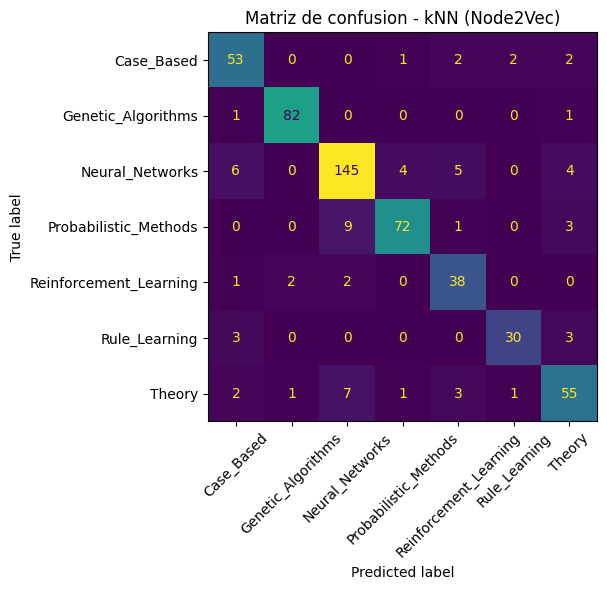

In [23]:
resultados_test = []
reportes_clase = {}
matrices_confusion = {}

for nombre, modelo in mejores_modelos.items():
    y_pred = modelo.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1_macro, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )
    resultados_test.append({
        "modelo": nombre,
        "accuracy": round(accuracy, 3),
        "precision_macro": round(precision, 3),
        "recall_macro": round(recall, 3),
        "f1_macro": round(f1_macro, 3),
    })
    reportes_clase[nombre] = classification_report(y_test, y_pred, zero_division=0)
    matrices_confusion[nombre] = confusion_matrix(y_test, y_pred, labels=np.unique(y_test))

resumen_test_n2v = pd.DataFrame(resultados_test).sort_values("f1_macro", ascending=False)
print("Resultados en test (Node2Vec - 64 features):")
display(resumen_test_n2v)

# Reporte y matriz de confusion del mejor modelo
mejor_nombre = resumen_test_n2v.iloc[0]["modelo"]
print(f"\nMejor modelo: {mejor_nombre}")
print(f"\nReporte por clase:\n{reportes_clase[mejor_nombre]}")

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(
    confusion_matrix=matrices_confusion[mejor_nombre],
    display_labels=np.unique(y_test),
).plot(ax=ax, xticks_rotation=45, colorbar=False)

# Guardar la matriz de confusion del mejor modelo
figuras_dir = BASE_DIR / "docs" / "trabajo" / "figuras"
figuras_dir.mkdir(parents=True, exist_ok=True)
salida_figura = figuras_dir / "matriz_confusion_kNN_Node2Vec.png"
fig.savefig(salida_figura, dpi=300, bbox_inches="tight")
print(f"\nFigura guardada en: {salida_figura}")

ax.set_title(f"Matriz de confusion - {mejor_nombre} (Node2Vec)")
plt.tight_layout()
plt.show()



## 7. Comparativa con baseline de caracteristicas manuales

Comparamos ambas estrategias de representacion. El baseline de la Tarea 2.1 usa 1437 variables (texto + topologia), mientras que Node2Vec resume estructura del grafo en 64 dimensiones densas aprendidas.

In [7]:
# Resultados baseline de la Tarea 2.1 (features manuales: 1433 texto + 4 topológicas)
baseline_tarea21 = pd.DataFrame([
    {"modelo": "Árbol de Decisión", "accuracy": 0.771, "f1_macro": 0.758, "precision_macro": 0.762, "recall_macro": 0.760},
    {"modelo": "MLP",               "accuracy": 0.730, "f1_macro": 0.717, "precision_macro": 0.721, "recall_macro": 0.717},
    {"modelo": "Naive Bayes",        "accuracy": 0.452, "f1_macro": 0.428, "precision_macro": 0.437, "recall_macro": 0.422},
    {"modelo": "kNN",                "accuracy": 0.422, "f1_macro": 0.416, "precision_macro": 0.469, "recall_macro": 0.406},
])
baseline_tarea21["estrategia"] = "Manual (1437 features)"

# Resultados actuales con Node2Vec
nombre_map = {"ArbolDecision": "Árbol de Decisión", "NaiveBayes": "Naive Bayes", "kNN": "kNN", "MLP": "MLP"}
n2v_resultados = resumen_test_n2v.copy()
n2v_resultados["modelo"] = n2v_resultados["modelo"].map(nombre_map)
n2v_resultados["estrategia"] = "Node2Vec (64 features)"

# Tabla comparativa unificada — F1-macro por modelo y estrategia
comparativa = pd.concat(
    [
        baseline_tarea21,
        n2v_resultados[["modelo", "accuracy", "f1_macro", "precision_macro", "recall_macro", "estrategia"]],
    ],
    ignore_index=True,
)

pivot = comparativa.pivot_table(
    index="modelo",
    columns="estrategia",
    values="f1_macro",
).round(3)

print("=== F1-macro: Características manuales vs. Node2Vec ===\n")
display(pivot)

# Resumen ejecutivo
mejor_n2v = resumen_test_n2v.iloc[0]
mejor_n2v_nombre = nombre_map.get(mejor_n2v["modelo"], mejor_n2v["modelo"])
print(f"\nMejor modelo Node2Vec : {mejor_n2v_nombre} — F1-macro = {mejor_n2v['f1_macro']:.3f}")
print(f"Mejor modelo manual   : Árbol de Decisión   — F1-macro = 0.758")
delta = mejor_n2v["f1_macro"] - 0.758
signo = "+" if delta >= 0 else ""
print(f"Diferencia            : {signo}{delta:.3f}")

=== F1-macro: Características manuales vs. Node2Vec ===



estrategia,Manual (1437 features),Node2Vec (64 features)
modelo,,
MLP,0.717,0.853
Naive Bayes,0.428,0.758
kNN,0.416,0.870
Árbol de Decisión,0.758,0.714



Mejor modelo Node2Vec : kNN — F1-macro = 0.870
Mejor modelo manual   : Árbol de Decisión   — F1-macro = 0.758
Diferencia            : +0.112


## 8. Persistencia de artefactos

Guardamos resultados de validacion y test junto con el mejor modelo para asegurar trazabilidad y reutilizacion en la Tarea 2.3.

In [24]:
from datetime import datetime
from joblib import dump

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
artifacts_dir = BASE_DIR / "artifacts" / "tarea_2_5" / timestamp
artifacts_dir.mkdir(parents=True, exist_ok=True)

resumen_test_n2v.to_csv(artifacts_dir / "resumen_test.csv", index=False)
resumen_cv_n2v.to_csv(artifacts_dir / "resumen_cv.csv", index=False)

mejor_nombre_n2v = str(resumen_test_n2v.iloc[0]["modelo"])
dump(mejores_modelos[mejor_nombre_n2v], artifacts_dir / f"modelo_{mejor_nombre_n2v}.joblib")

print(f"Artefactos de Tarea 2.5 guardados en: {artifacts_dir}")
print(f"Archivo de test: {artifacts_dir / 'resumen_test.csv'}")
print(f"Modelo guardado: {artifacts_dir / f'modelo_{mejor_nombre_n2v}.joblib'}")

Artefactos de Tarea 2.5 guardados en: c:\Users\juana\aprendizaje-automatico-relacional\artifacts\tarea_2_5\20260607_002814
Archivo de test: c:\Users\juana\aprendizaje-automatico-relacional\artifacts\tarea_2_5\20260607_002814\resumen_test.csv
Modelo guardado: c:\Users\juana\aprendizaje-automatico-relacional\artifacts\tarea_2_5\20260607_002814\modelo_kNN.joblib


## 9. Conclusiones y siguientes pasos

- Node2Vec permite comprimir informacion estructural del grafo en una representacion densa util para clasificacion multiclase.
- La comparativa final con el baseline manual cuantifica el aporte real de esta representacion aprendida.
- El modelo persistido en `artifacts/tarea_2_5/<timestamp>/` queda listo para la fase de seleccion final del proyecto.